In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

import pandas_datareader.data as web

In [2]:

# Подготовка датасета для обучения в формате inputs, outputs
def make_datasets(input_data, n_inputs=2, n_outputs=1, gap=0):
	L = len(input_data)
	y = np.full((L-n_inputs-n_outputs-gap, n_outputs), 0.0)
	X = np.full((L-n_inputs-n_outputs-gap, n_inputs), 0.0)

	for i in range(n_inputs):
		X[:,i] = input_data[i:L-n_inputs-n_outputs-gap+i]

	for i in range(n_outputs):
		y[:,i] = input_data[n_inputs+gap+i:L-n_outputs+i]

	return X, y

     

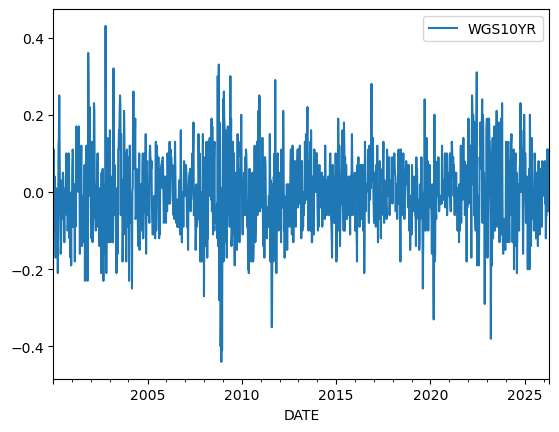

In [3]:
rate = web.DataReader(name='WGS10YR', data_source='fred', start='2000-01-01').diff().dropna()
rate.plot()
plt.show()

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
# Переведем ряда массив Numpy
series = rate.squeeze().to_numpy()

In [6]:
# задаём ширину окна и горизонт прогнозирования
n_lags, fh= 20, 10

X, y = make_datasets(series, n_inputs=n_lags, n_outputs=fh)

In [7]:
X_tensor = torch.Tensor(X).to(device)
y_tensor = torch.Tensor(y).to(device)

train_dataset = TensorDataset(X_tensor, y_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [8]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


In [9]:
# MLP с одним скрытым слоем
hidden_state = 40

model = nn.Sequential(
    nn.Linear(n_lags, hidden_state),
    nn.ReLU(),
    # nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(hidden_state, fh)
).to(device)

In [10]:
# Число параметров модели
for params in model.parameters():
  print(params.size())

torch.Size([40, 20])
torch.Size([40])
torch.Size([10, 40])
torch.Size([10])


In [11]:
len(series)

1372

In [12]:
hidden_state_1 = 40
hidden_state_2 = 20

In [13]:
#MLP с двумя скрытыми слоями

In [14]:
model2 = nn.Sequential(
    nn.Linear(n_lags, hidden_state_1),
    nn.ReLU(),
    nn.Linear(hidden_state_1, hidden_state_2),
    nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(hidden_state_2, fh)
).to(device)

In [15]:
# Число параметров модели
for params in model2.parameters():
  print(params.size())

torch.Size([40, 20])
torch.Size([40])
torch.Size([20, 40])
torch.Size([20])
torch.Size([10, 20])
torch.Size([10])


In [16]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.016486  [   64/ 1342]
loss: 0.011975  [  704/ 1342]
loss: 0.012620  [ 1302/ 1342]
Epoch 2
-------------------------------
loss: 0.010725  [   64/ 1342]
loss: 0.009822  [  704/ 1342]
loss: 0.009164  [ 1302/ 1342]
Epoch 3
-------------------------------
loss: 0.010893  [   64/ 1342]
loss: 0.008918  [  704/ 1342]
loss: 0.009355  [ 1302/ 1342]
Epoch 4
-------------------------------
loss: 0.009638  [   64/ 1342]
loss: 0.009762  [  704/ 1342]
loss: 0.011062  [ 1302/ 1342]
Epoch 5
-------------------------------
loss: 0.009590  [   64/ 1342]
loss: 0.011172  [  704/ 1342]
loss: 0.011126  [ 1302/ 1342]
Epoch 6
-------------------------------
loss: 0.009404  [   64/ 1342]
loss: 0.009049  [  704/ 1342]
loss: 0.010854  [ 1302/ 1342]
Epoch 7
-------------------------------
loss: 0.010903  [   64/ 1342]
loss: 0.009421  [  704/ 1342]
loss: 0.010506  [ 1302/ 1342]
Epoch 8
-------------------------------
loss: 0.009450  [   64/ 1342]
loss: 0.009374  [  7

In [17]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model2.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model2, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.172925  [   64/ 1342]
loss: 0.105640  [  704/ 1342]
loss: 0.068163  [ 1302/ 1342]
Epoch 2
-------------------------------
loss: 0.066338  [   64/ 1342]
loss: 0.046762  [  704/ 1342]
loss: 0.026175  [ 1302/ 1342]
Epoch 3
-------------------------------
loss: 0.030596  [   64/ 1342]
loss: 0.020605  [  704/ 1342]
loss: 0.016036  [ 1302/ 1342]
Epoch 4
-------------------------------
loss: 0.016012  [   64/ 1342]
loss: 0.013339  [  704/ 1342]
loss: 0.011502  [ 1302/ 1342]
Epoch 5
-------------------------------
loss: 0.011570  [   64/ 1342]
loss: 0.008996  [  704/ 1342]
loss: 0.009188  [ 1302/ 1342]
Epoch 6
-------------------------------
loss: 0.011708  [   64/ 1342]
loss: 0.010092  [  704/ 1342]
loss: 0.008768  [ 1302/ 1342]
Epoch 7
-------------------------------
loss: 0.009768  [   64/ 1342]
loss: 0.010672  [  704/ 1342]
loss: 0.009078  [ 1302/ 1342]
Epoch 8
-------------------------------
loss: 0.010559  [   64/ 1342]
loss: 0.009493  [  7

In [18]:
inputs = torch.Tensor(series[-n_lags:]).unsqueeze(0) # переведём в тензор (1, n_lags)

model.eval()
with torch.no_grad():  # Отключаем вычисление градиентов
	outputs = model(inputs) # получаем тензор размера (1, fh)

outputs.squeeze() # переведём в одномерный тензор

tensor([-0.0079, -0.0031, -0.0067, -0.0005, -0.0120, -0.0109, -0.0014, -0.0034,
         0.0060, -0.0024])

In [19]:
model2.eval()
with torch.no_grad():  # Отключаем вычисление градиентов
	outputs2 = model2(inputs) # получаем тензор размера (1, fh)

outputs2.squeeze() # переведём в одномерный тензор

tensor([ 0.0016,  0.0002, -0.0081, -0.0054, -0.0049, -0.0034, -0.0010, -0.0034,
        -0.0061,  0.0026])

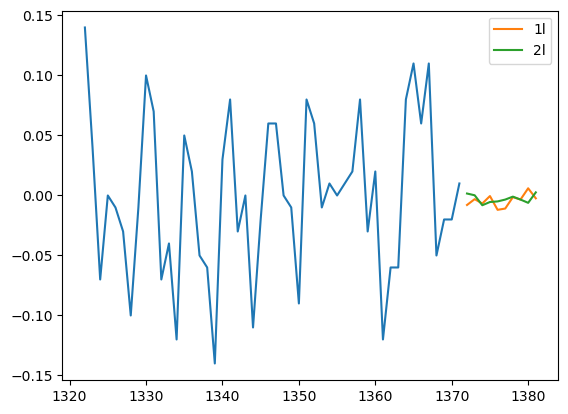

In [21]:
last_obs = 50

y_pred = outputs.squeeze().numpy()
y_pred2 = outputs2.squeeze().numpy()

plt.plot(np.arange(len(series)-last_obs, len(series)), series[-last_obs:])
plt.plot(np.arange(len(series), len(series)+fh), y_pred, label='1l')
plt.plot(np.arange(len(series), len(series)+fh), y_pred2, label='2l')
plt.legend()
plt.show()

In [22]:
from torch.utils.data import random_split

In [23]:
# Подготовка датасета для обучения в формате inputs, outputs
def make_datasets(input_data, n_inputs=2, n_outputs=1, gap=0):
	L = len(input_data)
	y = np.full((L-n_inputs-n_outputs-gap, n_outputs), 0.0)
	X = np.full((L-n_inputs-n_outputs-gap, n_inputs), 0.0)

	for i in range(n_inputs):
		X[:,i] = input_data[i:L-n_inputs-n_outputs-gap+i]

	for i in range(n_outputs):
		y[:,i] = input_data[n_inputs+gap+i:L-n_outputs+i]

	return X, y

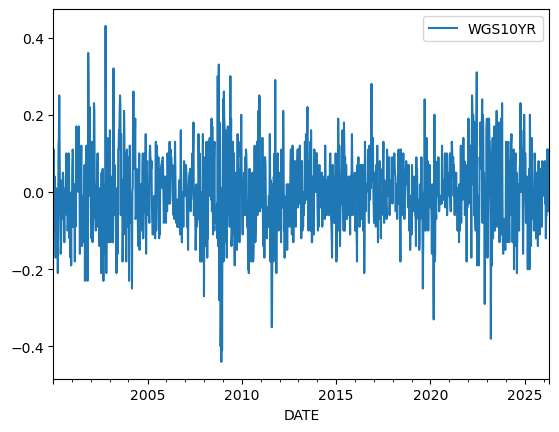

In [24]:
rate = web.DataReader(name='WGS10YR', data_source='fred', start='2000-01-01').diff().dropna()
rate.plot()
plt.show()

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [26]:
# Переведем ряда массив Numpy
series = rate.squeeze().to_numpy()

In [27]:
# задаём ширину окна и горизонт прогнозирования
n_lags, fh= 20, 10

X, y = make_datasets(series, n_inputs=n_lags, n_outputs=fh)

In [28]:
X_tensor = torch.Tensor(X).to(device)
y_tensor = torch.Tensor(y).to(device)

dataset = TensorDataset(X_tensor, y_tensor)

# Для воспроизводимости задаём генератор
generator = torch.Generator().manual_seed(42)
# делим выборку на обучающую и тестовую с соотношении 80:20
train_dataset, test_dataset = random_split(dataset, [0.8, 0.2], generator=generator)

# Создаём DataLoader'ы
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [29]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model.train()                                 # переводим молель в режим обучения
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()                     # Очищаем старые градиенты
        # Compute prediction error
        y_pred = model(X)                         # строми прооноз на батче
        loss = loss_fn(y_pred, y)                 # вычисляем ошибку проноза/значение функции потерь

        # Backpropagation
        loss.backward()                           # Вычисляем градиенты
        optimizer.step()                          # Обновляем веса по градиентам

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: Avg loss = {test_loss:>8f} \n")

In [30]:
# MLP с одним скрытым слоем
hidden_state = 30

model = nn.Sequential(
    nn.Linear(n_lags, hidden_state),
    nn.ReLU(),
    # nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(hidden_state, fh)
).to(device)

In [31]:
hidden_state_1 = 40
hidden_state_2 = 20

model2 = nn.Sequential(
    nn.Linear(n_lags, hidden_state_1),
    nn.ReLU(),
    nn.Linear(hidden_state_1, hidden_state_2),
    nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(hidden_state_2, fh)
).to(device)

In [32]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.020693  [   32/ 1074]
loss: 0.013495  [  352/ 1074]
loss: 0.012969  [  672/ 1074]
loss: 0.009920  [  992/ 1074]
Epoch 2
-------------------------------
loss: 0.012564  [   32/ 1074]
loss: 0.011870  [  352/ 1074]
loss: 0.009753  [  672/ 1074]
loss: 0.010248  [  992/ 1074]
Epoch 3
-------------------------------
loss: 0.010191  [   32/ 1074]
loss: 0.012674  [  352/ 1074]
loss: 0.009560  [  672/ 1074]
loss: 0.008910  [  992/ 1074]
Epoch 4
-------------------------------
loss: 0.011830  [   32/ 1074]
loss: 0.009975  [  352/ 1074]
loss: 0.009543  [  672/ 1074]
loss: 0.008880  [  992/ 1074]
Epoch 5
-------------------------------
loss: 0.012411  [   32/ 1074]
loss: 0.008932  [  352/ 1074]
loss: 0.009455  [  672/ 1074]
loss: 0.011745  [  992/ 1074]
Epoch 6
-------------------------------
loss: 0.010984  [   32/ 1074]
loss: 0.008733  [  352/ 1074]
loss: 0.011342  [  672/ 1074]
loss: 0.012024  [  992/ 1074]
Epoch 7
-------------------------------


In [33]:
# Обучение
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model2.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
	print(f"Epoch {epoch+1}\n-------------------------------")
	train(train_dataloader, model2, loss_fn, optimizer)

print("Done!")

Epoch 1
-------------------------------
loss: 0.101269  [   32/ 1074]
loss: 0.048463  [  352/ 1074]
loss: 0.020807  [  672/ 1074]
loss: 0.012333  [  992/ 1074]
Epoch 2
-------------------------------
loss: 0.010707  [   32/ 1074]
loss: 0.009172  [  352/ 1074]
loss: 0.009910  [  672/ 1074]
loss: 0.012901  [  992/ 1074]
Epoch 3
-------------------------------
loss: 0.009567  [   32/ 1074]
loss: 0.008470  [  352/ 1074]
loss: 0.011399  [  672/ 1074]
loss: 0.011314  [  992/ 1074]
Epoch 4
-------------------------------
loss: 0.009517  [   32/ 1074]
loss: 0.007197  [  352/ 1074]
loss: 0.010849  [  672/ 1074]
loss: 0.007547  [  992/ 1074]
Epoch 5
-------------------------------
loss: 0.008490  [   32/ 1074]
loss: 0.010454  [  352/ 1074]
loss: 0.008646  [  672/ 1074]
loss: 0.011575  [  992/ 1074]
Epoch 6
-------------------------------
loss: 0.010826  [   32/ 1074]
loss: 0.010162  [  352/ 1074]
loss: 0.008774  [  672/ 1074]
loss: 0.008846  [  992/ 1074]
Epoch 7
-------------------------------


In [34]:
# метрики на тестово множества
test(test_dataloader, model, loss_fn)

Test Error: Avg loss = 0.010128 



In [35]:
# метрики на тестово множества
test(test_dataloader, model2, loss_fn)

Test Error: Avg loss = 0.010087 

